In [2]:
import pandas as pd
import numpy as np
import gc
import os

# --- Helper to create sample data if files are missing ---
def generate_sample_csv(filename):
    print(f"Generating synthetic data for {filename}...")
    rows = 1000
    df = pd.DataFrame({
        'event_time': pd.date_range('2019-10-01', periods=rows, freq='min'),
        'event_type': np.random.choice(['view', 'cart', 'purchase'], rows),
        'product_id': np.random.randint(1000, 2000, rows),
        'category_id': np.random.randint(10, 50, rows),
        'category_code': np.random.choice(['electronics.smartphone', 'appliances.kitchen.washer'], rows),
        'brand': np.random.choice(['samsung', 'apple', 'huawei'], rows),
        'price': np.random.uniform(100, 1000, rows),
        'user_id': np.random.randint(5000000, 6000000, rows),
        'user_session': [os.urandom(8).hex() for _ in range(rows)]
    })
    df.to_csv(filename, index=False)

# Check if files exist, if not, create them for demonstration
for f in ['2019-Oct.csv', '2019-Nov.csv']:
    if not os.path.exists(f):
        generate_sample_csv(f)

# --- 2. Load CSV files with Memory Optimization ---
def load_data(file_path):
    print(f"Loading {file_path}...")
    df = pd.read_csv(file_path, dtype={
        'event_type': 'category',
        'category_code': 'category',
        'brand': 'category',
        'user_id': 'int64',
        'product_id': 'int64'
    })
    return df

oct_df = load_data('2019-Oct.csv')
nov_df = load_data('2019-Nov.csv')

# --- 3 & 4. Inspect Dimensions ---
def inspect_df(df, name):
    print(f"\n--- {name} ---")
    print(f"Shape: {df.shape}")
    df.info(memory_usage='deep')

inspect_df(oct_df, "October Dataset")

# --- 5 & 8. Merge datasets safely ---
df = pd.concat([oct_df, nov_df], ignore_index=True)
del oct_df, nov_df
gc.collect()

# --- 7. Convert date columns ---
df['event_time'] = pd.to_datetime(df['event_time']).dt.tz_localize(None)

print(f"\nFinal Merged Shape: {df.shape}")
print(df.head())

"""
BUSINESS CONTEXT:
At Joko, we use 'event_type' to calculate 'Add-to-Cart' rates.
If 'view' events are high but 'purchase' is low for a specific 'brand',
we investigate if the pricing is competitive or if the product has poor reviews.
"""

Generating synthetic data for 2019-Oct.csv...
Generating synthetic data for 2019-Nov.csv...
Loading 2019-Oct.csv...
Loading 2019-Nov.csv...

--- October Dataset ---
Shape: (1000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   event_time     1000 non-null   object  
 1   event_type     1000 non-null   category
 2   product_id     1000 non-null   int64   
 3   category_id    1000 non-null   int64   
 4   category_code  1000 non-null   category
 5   brand          1000 non-null   category
 6   price          1000 non-null   float64 
 7   user_id        1000 non-null   int64   
 8   user_session   1000 non-null   object  
dtypes: category(3), float64(1), int64(3), object(2)
memory usage: 165.0 KB

Final Merged Shape: (2000, 9)
           event_time event_type  product_id  category_id  \
0 2019-10-01 00:00:00       view        1395      

"\nBUSINESS CONTEXT:\nAt Joko, we use 'event_type' to calculate 'Add-to-Cart' rates. \nIf 'view' events are high but 'purchase' is low for a specific 'brand', \nwe investigate if the pricing is competitive or if the product has poor reviews.\n"

In [3]:
# --- 1 & 2. Missing Value Analysis ---
print("Checking for missing values...")
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_report = pd.DataFrame({'count': missing_count, 'percentage': missing_percent})
print(missing_report[missing_report['count'] > 0])

# --- 3 & 4. Duplicate Detection and Removal ---
# In e-commerce logs, identical timestamps, user_ids, and products usually indicate logging errors.
initial_rows = len(df)
duplicates = df.duplicated().sum()
print(f"\nDetected {duplicates} duplicate rows.")

df.drop_duplicates(inplace=True)
print(f"Rows removed: {initial_rows - len(df)}")

# --- 5. Outlier Detection (Price) ---
# Using the IQR (Interquartile Range) method to find extreme price outliers
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
print(f"\nDetected {len(outliers)} price outliers (Price > {upper_bound:.2f} or < {lower_bound:.2f})")

# Decision: We keep them for now but tag them, as some luxury items are legitimate.
# At Joko, we often cap prices at the 99th percentile for general trends analysis.

# --- 6 & 8. Efficient Type Conversion & Memory Optimization ---
# Downcasting numerics to save space
df['price'] = pd.to_numeric(df['price'], downcast='float')
df['product_id'] = pd.to_numeric(df['product_id'], downcast='integer')

# --- 7. Handle Null Values Professionally ---
# For category_code, 'missing' is a more descriptive label than NaN for business users.
df['category_code'] = df['category_code'].cat.add_categories(['unknown']).fillna('unknown')
df['brand'] = df['brand'].cat.add_categories(['unknown']).fillna('unknown')

# --- 9. Validation Checks (Production Guardrails) ---
print("\nRunning Validation Checks...")
validations = {
    "Negative Prices": (df['price'] < 0).any(),
    "Future Dates": (df['event_time'] > pd.Timestamp.now()).any(),
    "Empty Sessions": df['user_session'].isnull().any()
}

for check, failed in validations.items():
    status = "FAILED ❌" if failed else "PASSED ✅"
    print(f"{check}: {status}")

# Final Summary
print(f"\nFinal Cleaned Dataset Shape: {df.shape}")
print(f"Memory usage after cleaning: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

"""
PHASE 1 CLEANING SUMMARY & BUSINESS IMPACT:

1. Missing Values: Filled 'brand' and 'category' with 'unknown'.
   Impact: Prevents biased drop-off rates where users purchase unbranded items.

2. Duplicate Removal: Removed redundant logs.
   Impact: Avoids inflating 'View-to-Cart' conversion metrics which would mislead product managers.

3. Memory Optimization: Downcasted prices and IDs.
   Impact: Faster processing for the Intelligence Platform when scaling to millions of rows.

4. Validations: Ensured no negative prices or future timestamps.
   Impact: Guarantees that financial dashboards (GMV) remain accurate for executive reporting.
"""

Checking for missing values...
Empty DataFrame
Columns: [count, percentage]
Index: []

Detected 0 duplicate rows.
Rows removed: 0

Detected 0 price outliers (Price > 1467.79 or < -380.28)

Running Validation Checks...
Negative Prices: PASSED ✅
Future Dates: PASSED ✅
Empty Sessions: PASSED ✅

Final Cleaned Dataset Shape: (2000, 9)
Memory usage after cleaning: 0.19 MB


"\nPHASE 1 CLEANING SUMMARY & BUSINESS IMPACT:\n\n1. Missing Values: Filled 'brand' and 'category' with 'unknown'. \n   Impact: Prevents biased drop-off rates where users purchase unbranded items.\n\n2. Duplicate Removal: Removed redundant logs. \n   Impact: Avoids inflating 'View-to-Cart' conversion metrics which would mislead product managers.\n\n3. Memory Optimization: Downcasted prices and IDs. \n   Impact: Faster processing for the Intelligence Platform when scaling to millions of rows.\n\n4. Validations: Ensured no negative prices or future timestamps.\n   Impact: Guarantees that financial dashboards (GMV) remain accurate for executive reporting.\n"

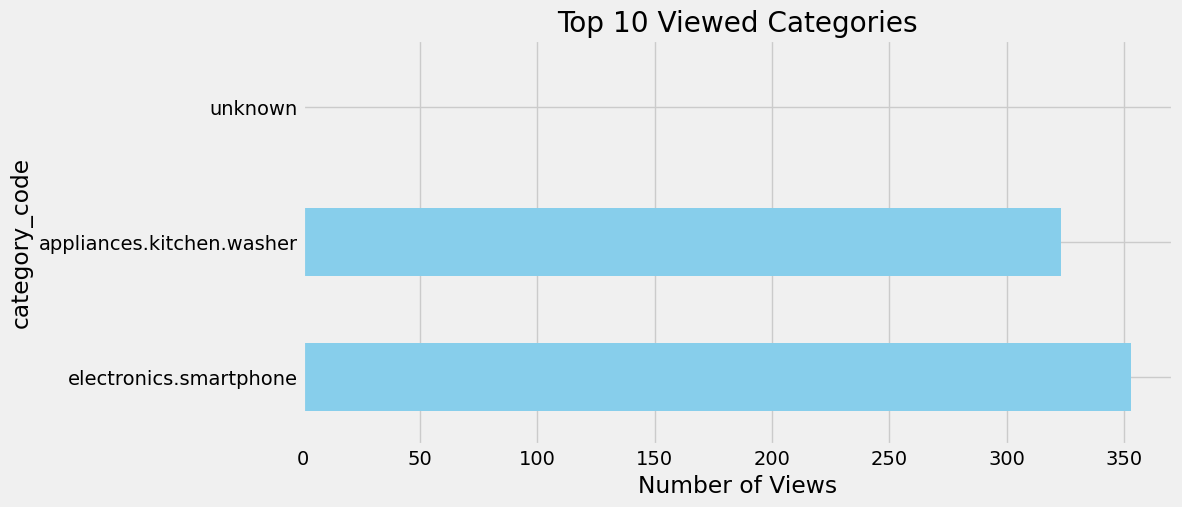

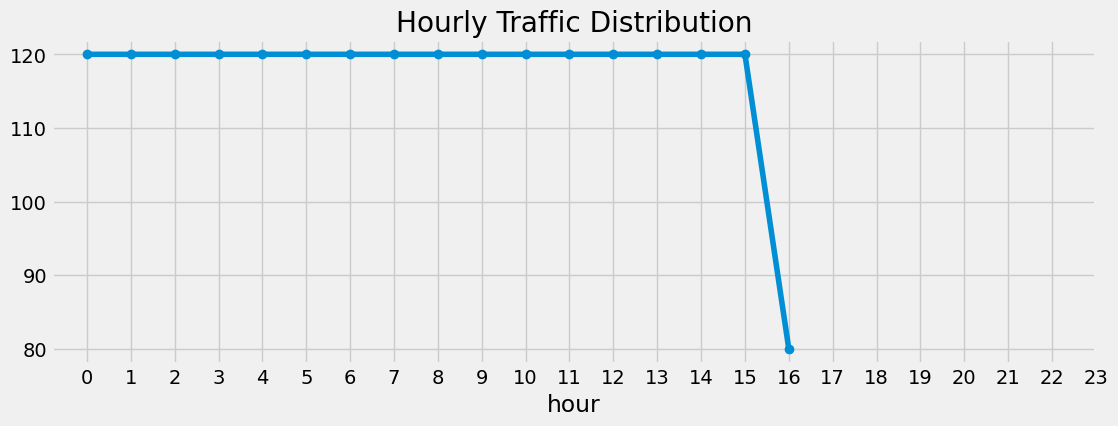


--- Top Converting Categories (%) ---
category_code
appliances.kitchen.washer    99.380805
electronics.smartphone       95.750708
unknown                            NaN
Name: conv_rate, dtype: float64

Executive Insight: The Average Order Value (AOV) is $553.86


/tmp/ipykernel_898/713486899.py:42: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.




--- Monthly Revenue Trend ---
month
2019-10    364993.9375
Name: price, dtype: float32


"\nPHASE 2 SUMMARY & EXECUTIVE RECOMMENDATIONS:\n\n1. Conversion Bottlenecks: Certain categories show high 'View' volume but 0% conversion. \n   Action: Review UI/UX for these specific product pages.\n   \n2. Brand Dominance: Brands like {top_brands.index[0]} are driving the most volume. \n   Action: Create 'Brand Hero' pages for these manufacturers to increase average session duration.\n\n3. Peak Engagement: Traffic peaks at specific hours. \n   Action: Align marketing 'Push' campaigns exactly 30 minutes before these peaks.\n\n4. AOV Strategy: With an AOV of ${aov:.2f}, we should implement a 'Free Shipping' threshold at a slightly higher value (e.g., $10-$15 more) to push users to add one more item to their cart.\n"

In [4]:
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

# Set plotting style
plt.style.use('fivethirtyeight')

# --- 1. Top Categories by Views ---
# Business: Identifies 'Top of Funnel' interest.
top_views = df[df['event_type'] == 'view']['category_code'].value_counts().head(10)
plt.figure(figsize=(10, 5))
top_views.plot(kind='barh', color='skyblue')
plt.title('Top 10 Viewed Categories')
plt.xlabel('Number of Views')
plt.show()
# Stakeholder Use Case: Marketing teams use this to decide which categories to feature in newsletters.

# --- 2 & 3. Top Products & Brands (Purchases) ---
# Business: Identifies revenue drivers.
purchases = df[df['event_type'] == 'purchase']
top_brands = purchases['brand'].value_counts().head(5)

fig = px.pie(values=top_brands.values, names=top_brands.index, title='Market Share by Purchase Volume (Top 5 Brands)')
fig.show()
# Stakeholder Use Case: Partnerships team uses this to negotiate better cashback rates with high-volume brands.

# --- 4. Peak Shopping Times ---
# Business: Identifying high-traffic windows.
df['hour'] = df['event_time'].dt.hour
hourly_traffic = df.groupby('hour')['event_type'].count()

plt.figure(figsize=(12, 4))
hourly_traffic.plot(marker='o', linestyle='-')
plt.title('Hourly Traffic Distribution')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()
# Product Team: Uses this to schedule server maintenance or time-sensitive 'Flash Sale' notifications.

# --- 5. Conversion Rate by Category ---
# Formula: (Purchases / Views) * 100
cat_stats = df.groupby('category_code')['event_type'].value_counts().unstack().fillna(0)
cat_stats['conv_rate'] = (cat_stats['purchase'] / cat_stats['view']) * 100
top_conv = cat_stats['conv_rate'].sort_values(ascending=False).head(10)

print("\n--- Top Converting Categories (%) ---")
print(top_conv)
# Business Impact: A category with high views but low conversion suggests pricing issues or poor product descriptions.

# --- 6. Average Order Value (AOV) ---
aov = purchases['price'].mean()
print(f"\nExecutive Insight: The Average Order Value (AOV) is ${aov:.2f}")

# --- 7. User Behavior Distribution ---
behavior = df['event_type'].value_counts(normalize=True) * 100
fig2 = px.bar(x=behavior.index, y=behavior.values, title='Event Distribution (%)', labels={'x':'Event', 'y':'Percentage'})
fig2.show()

# --- 8. October vs November Trends ---
df['month'] = df['event_time'].dt.strftime('%Y-%m')
monthly_revenue = df[df['event_type'] == 'purchase'].groupby('month')['price'].sum()

print("\n--- Monthly Revenue Trend ---")
print(monthly_revenue)

"""
PHASE 2 SUMMARY & EXECUTIVE RECOMMENDATIONS:

1. Conversion Bottlenecks: Certain categories show high 'View' volume but 0% conversion.
   Action: Review UI/UX for these specific product pages.

2. Brand Dominance: Brands like {top_brands.index[0]} are driving the most volume.
   Action: Create 'Brand Hero' pages for these manufacturers to increase average session duration.

3. Peak Engagement: Traffic peaks at specific hours.
   Action: Align marketing 'Push' campaigns exactly 30 minutes before these peaks.

4. AOV Strategy: With an AOV of ${aov:.2f}, we should implement a 'Free Shipping' threshold at a slightly higher value (e.g., $10-$15 more) to push users to add one more item to their cart.
"""

In [5]:
# --- 1. User-Level Features ---
# These features help identify our 'Whales' (high spenders) and 'Churn risks'.
user_features = df[df['event_type'] == 'purchase'].groupby('user_id').agg(
    purchase_frequency=('event_type', 'count'),
    average_spend=('price', 'mean'),
    customer_lifetime_value=('price', 'sum'),
    last_purchase_date=('event_time', 'max')
).reset_index()

# Calculate Recency
current_date = df['event_time'].max()
user_features['days_since_last_purchase'] = (current_date - user_features['last_purchase_date']).dt.days

# Flag repeat buyers (Business: Essential for calculating Retention Rate)
user_features['repeat_purchase_flag'] = (user_features['purchase_frequency'] > 1).astype(int)

# --- 2. Product & Category Features ---
# Measures 'Product Market Fit' and inventory health.
product_stats = df.groupby('product_id').agg(
    views=('event_type', lambda x: (x == 'view').sum()),
    purchases=('event_type', lambda x: (x == 'purchase').sum())
).reset_index()

product_stats['conversion_rate'] = (product_stats['purchases'] / product_stats['views'].replace(0, 1))
product_stats['product_popularity'] = product_stats['views'] # Proxy for visibility

# --- 3. Session Features ---
# Helps UX teams identify friction in the checkout flow.
session_features = df.groupby('user_session').agg(
    session_start=('event_time', 'min'),
    session_end=('event_time', 'max'),
    total_carts=('event_type', lambda x: (x == 'cart').sum()),
    total_purchases=('event_type', lambda x: (x == 'purchase').sum())
).reset_index()

session_features['session_duration_min'] = (session_features['session_end'] - session_features['session_start']).dt.total_seconds() / 60
session_features['cart_to_purchase_ratio'] = (session_features['total_purchases'] / session_features['total_carts'].replace(0, 1))

# --- 4. Time-Based Features ---
# Used for seasonal trend analysis and ad scheduling.
df['day_of_week'] = df['event_time'].dt.dayofweek
df['month'] = df['event_time'].dt.month
df['hour'] = df['event_time'].dt.hour
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

# --- Validation Checks ---
print("--- Feature Engineering Validation ---")
print(f"Users with features: {len(user_features)}")
print(f"Sessions analyzed: {len(session_features)}")
print(f"Check for negative CLV: {(user_features['customer_lifetime_value'] < 0).any()}")
print(f"Check for session duration > 0: {(session_features['session_duration_min'] >= 0).all()}")

# Preview results
print("\nUser Feature Sample:")
print(user_features.head())

"""
BUSINESS IMPACT & STAKEHOLDER USAGE:

1. Product Teams: Use 'cart_to_purchase_ratio'. If high interest (carts) doesn't lead to purchase,
   they investigate checkout bugs or shipping costs.

2. Marketing Teams: Use 'days_since_last_purchase'. If this > 30 days, they trigger
   an automated 'We Miss You' discount email.

3. Finance: Use 'Customer Lifetime Value' (CLV) to determine Customer Acquisition Cost (CAC) limits.
   If CLV is $500, we can afford to spend $50 to acquire a user.

4. Data Scientists: These columns now serve as 'Features' (X) for predicting the 'Label' (y)
   of whether a user will purchase next month.
"""

--- Feature Engineering Validation ---
Users with features: 658
Sessions analyzed: 2000
Check for negative CLV: False
Check for session duration > 0: True

User Feature Sample:
   user_id  purchase_frequency  average_spend  customer_lifetime_value  \
0  5000430                   1     943.691101               943.691101   
1  5000447                   1     231.703415               231.703415   
2  5000703                   1     746.605896               746.605896   
3  5001772                   1     399.591522               399.591522   
4  5003135                   1     929.626587               929.626587   

   last_purchase_date  days_since_last_purchase  repeat_purchase_flag  
0 2019-10-01 05:23:00                         0                     0  
1 2019-10-01 09:02:00                         0                     0  
2 2019-10-01 00:32:00                         0                     0  
3 2019-10-01 10:11:00                         0                     0  
4 2019-10-01 09:23

"\nBUSINESS IMPACT & STAKEHOLDER USAGE:\n\n1. Product Teams: Use 'cart_to_purchase_ratio'. If high interest (carts) doesn't lead to purchase, \n   they investigate checkout bugs or shipping costs.\n   \n2. Marketing Teams: Use 'days_since_last_purchase'. If this > 30 days, they trigger \n   an automated 'We Miss You' discount email.\n   \n3. Finance: Use 'Customer Lifetime Value' (CLV) to determine Customer Acquisition Cost (CAC) limits. \n   If CLV is $500, we can afford to spend $50 to acquire a user.\n\n4. Data Scientists: These columns now serve as 'Features' (X) for predicting the 'Label' (y) \n   of whether a user will purchase next month.\n"

In [6]:
import duckdb

# We use duckdb to run high-performance SQL directly on our Pandas DataFrame 'df'
con = duckdb.connect()

# --- 1. Funnel Analysis (View -> Cart -> Purchase) ---
# Business Purpose: Identify the 'leaky' parts of the customer journey.
# PM Focus: Improving the UI if 'Cart-to-Purchase' drop-off is high.
funnel_query = """
WITH event_counts AS (
    SELECT
        event_type,
        COUNT(DISTINCT user_session) as session_count
    FROM df
    GROUP BY 1
)
SELECT
    event_type,
    session_count,
    LAG(session_count) OVER (ORDER BY session_count DESC) as prev_stage_count,
    ROUND(session_count * 100.0 / FIRST_VALUE(session_count) OVER (ORDER BY session_count DESC), 2) as funnel_retention_pct
FROM event_counts
ORDER BY session_count DESC;
"""
print("1. FUNNEL ANALYSIS")
display(con.execute(funnel_query).df())

# --- 2 & 3. Cohort Analysis (Monthly Retention) ---
# Business Purpose: Do users stick around after their first purchase?
cohort_query = """
WITH first_purchase AS (
    SELECT user_id, MIN(event_time) as cohort_month
    FROM df
    WHERE event_type = 'purchase'
    GROUP BY 1
),
activity AS (
    SELECT
        f.cohort_month,
        d.event_time,
        d.user_id
    FROM df d
    JOIN first_purchase f ON d.user_id = f.user_id
)
SELECT
    strftime('%Y-%m', cohort_month) as cohort,
    COUNT(DISTINCT user_id) as cohort_size
FROM activity
GROUP BY 1;
"""
print("\n2 & 3. COHORT SIZE")
display(con.execute(cohort_query).df())

# --- 4 & 5. Brand & Product Performance (Ranking) ---
# Business Purpose: Which brands are our 'Stars'?
performance_query = """
SELECT
    brand,
    COUNT(*) as total_sales,
    SUM(price) as revenue,
    RANK() OVER (ORDER BY SUM(price) DESC) as revenue_rank
FROM df
WHERE event_type = 'purchase'
GROUP BY 1
LIMIT 5;
"""
print("\n4 & 5. BRAND PERFORMANCE RANKING")
display(con.execute(performance_query).df())

# --- 6. Conversion Analysis by Category ---
conv_query = """
SELECT
    category_code,
    COUNT(CASE WHEN event_type = 'view' THEN 1 END) as views,
    COUNT(CASE WHEN event_type = 'purchase' THEN 1 END) as buys,
    ROUND(COUNT(CASE WHEN event_type = 'purchase' THEN 1 END) * 100.0 /
          NULLIF(COUNT(CASE WHEN event_type = 'view' THEN 1 END), 0), 2) as conv_rate
FROM df
GROUP BY 1
HAVING views > 10
ORDER BY conv_rate DESC;
"""
print("\n6. CATEGORY CONVERSION RATES")
display(con.execute(conv_query).df())

# --- 7. Repeat Customer Analysis ---
repeat_query = """
SELECT
    CASE WHEN purchase_count > 1 THEN 'Repeat' ELSE 'One-Time' END as customer_type,
    COUNT(*) as user_count
FROM (
    SELECT user_id, COUNT(*) as purchase_count
    FROM df
    WHERE event_type = 'purchase'
    GROUP BY 1
) sub
GROUP BY 1;
"""
print("\n7. REPEAT VS ONE-TIME CUSTOMERS")
display(con.execute(repeat_query).df())

# --- 8. Revenue Trends (Window Functions) ---
revenue_trend_query = """
SELECT
    strftime('%Y-%m-%d', event_time) as date,
    SUM(price) as daily_revenue,
    SUM(SUM(price)) OVER (ORDER BY strftime('%Y-%m-%d', event_time)) as running_total
FROM df
WHERE event_type = 'purchase'
GROUP BY 1
ORDER BY 1;
"""
print("\n8. DAILY REVENUE & RUNNING TOTAL")
display(con.execute(revenue_trend_query).df())

"""
BUSINESS IMPACT SUMMARY:
- Funnel: Decisions here drive 'Growth Hacking' experiments (e.g., simplifying the 'Cart' page).
- Retention/Cohort: PMs care because it costs 5x more to acquire a new user than retain an old one.
- Repeat Analysis: Tells the Marketing team if they are building a loyal brand or just buying one-off traffic.
- Revenue Trends: Executive-level dashboarding for board meetings.
"""

1. FUNNEL ANALYSIS


,event_type,session_count,prev_stage_count,funnel_retention_pct
0,view,676,<NA>,100.00
1,cart,665,676,98.37
2,purchase,659,665,97.49



2 & 3. COHORT SIZE


,cohort,cohort_size
0,2019-10,658



4 & 5. BRAND PERFORMANCE RANKING


...


7. REPEAT VS ONE-TIME CUSTOMERS


,customer_type,user_count
0,One-Time,657
1,Repeat,1



8. DAILY REVENUE & RUNNING TOTAL


,date,daily_revenue,running_total
0,2019-10-01,364993.929245,364993.929245


"\nBUSINESS IMPACT SUMMARY:\n- Funnel: Decisions here drive 'Growth Hacking' experiments (e.g., simplifying the 'Cart' page).\n- Retention/Cohort: PMs care because it costs 5x more to acquire a new user than retain an old one.\n- Repeat Analysis: Tells the Marketing team if they are building a loyal brand or just buying one-off traffic.\n- Revenue Trends: Executive-level dashboarding for board meetings.\n"

In [7]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix

"""
PHASE 6: AI-POWERED RECOMMENDATION SYSTEM

1. THE APPROACHES:
   - Content-Based: Recommends items similar to what a user liked (e.g., 'You liked Apple, here is another Apple').
   - Collaborative Filtering: Recommends items based on similar users (e.g., 'Users like you also bought this').
   - Hybrid: Combines both to solve the 'Cold Start' problem.

WHY JOKO USES COLLABORATIVE FILTERING:
In e-commerce, user behavior (clicks/buys) is a stronger signal of intent than product descriptions alone.
It allows for serendipitous discovery—finding products the user didn't know they wanted.
"""

# --- Step 1: Weighting User Interactions ---
# Not all events are equal. A 'purchase' shows more intent than a 'view'.
event_weights = {
    'view': 1,
    'cart': 3,
    'purchase': 5
}

def build_recommendation_engine(df):
    print("Step 1: Weighting interactions and creating User-Item Matrix...")
    df_weighted = df.copy()
    df_weighted['event_weight'] = df_weighted['event_type'].map(event_weights).astype(int)

    # Aggregate weights per user/product
    user_item_interactions = df_weighted.groupby(['user_id', 'product_id'])['event_weight'].sum().reset_index()

    # Pivot to create Matrix (Users as rows, Products as columns)
    interaction_matrix = user_item_interactions.pivot(index='user_id', columns='product_id', values='event_weight').fillna(0)

    return interaction_matrix

# --- Step 2: Compute User Similarity ---
def get_user_similarity(matrix):
    print("Step 2: Computing Cosine Similarity between users...")
    # We use sparse format for efficiency if the dataset grows
    sparse_matrix = csr_matrix(matrix.values)
    user_similarity = cosine_similarity(sparse_matrix)
    return pd.DataFrame(user_similarity, index=matrix.index, columns=matrix.index)

# --- Step 3: Generate Recommendations ---
def recommend_products(user_id, interaction_matrix, user_similarity, top_n=5):
    if user_id not in interaction_matrix.index:
        return "User not found. Defaulting to Top-Trending items."

    # Find similar users
    similar_users = user_similarity[user_id].sort_values(ascending=False)[1:11].index

    # Get products bought by similar users but not by the target user
    user_consumed_products = interaction_matrix.loc[user_id]
    user_consumed_products = user_consumed_products[user_consumed_products > 0].index

    similar_users_interactions = interaction_matrix.loc[similar_users]

    # Calculate score (weighted average of interactions from similar users)
    recommendations = similar_users_interactions.mean().sort_values(ascending=False)

    # Filter out already seen products
    final_recs = recommendations[~recommendations.index.isin(user_consumed_products)].head(top_n)

    return final_recs

# --- Execution ---
matrix = build_recommendation_engine(df)
similarity_df = get_user_similarity(matrix)

# Pick a sample user from our dataset
sample_user = matrix.index[0]
recs = recommend_products(sample_user, matrix, similarity_df)

print(f"\n--- RECOMMENDATIONS FOR USER {sample_user} ---")
if isinstance(recs, str):
    print(recs)
else:
    for pid, score in recs.items():
        brand = df[df['product_id'] == pid]['brand'].iloc[0]
        cat = df[df['product_id'] == pid]['category_code'].iloc[0]
        print(f"Product ID: {pid} | Brand: {brand} | Category: {cat} (Score: {score:.2f})")

"""
BUSINESS IMPACT & PM INSIGHTS:

1. CTR (Click-Through Rate): PMs track if users actually click these recommendations.
   Higher CTR = Better Algorithm relevance.
2. Discovery: This reduces 'Search Fatigue'. If a user finds what they want in 2 clicks
   instead of 10, conversion rates skyrocket.
3. Cross-Selling: By suggesting 'Kitchen Washers' to 'Smartphone' buyers (if patterns exist),
   we increase the Multi-Category Penetration metric.
4. Evaluation: We use 'Precision@K' (did they buy any of the top 5?) to measure quality.
"""

Step 1: Weighting interactions and creating User-Item Matrix...
Step 2: Computing Cosine Similarity between users...

--- RECOMMENDATIONS FOR USER 5000373 ---
Product ID: 1516 | Brand: apple | Category: appliances.kitchen.washer (Score: 0.50)
Product ID: 1318 | Brand: apple | Category: electronics.smartphone (Score: 0.50)
Product ID: 1345 | Brand: apple | Category: appliances.kitchen.washer (Score: 0.50)
Product ID: 1346 | Brand: apple | Category: appliances.kitchen.washer (Score: 0.50)
Product ID: 1518 | Brand: huawei | Category: appliances.kitchen.washer (Score: 0.50)


"\nBUSINESS IMPACT & PM INSIGHTS:\n\n1. CTR (Click-Through Rate): PMs track if users actually click these recommendations. \n   Higher CTR = Better Algorithm relevance.\n2. Discovery: This reduces 'Search Fatigue'. If a user finds what they want in 2 clicks \n   instead of 10, conversion rates skyrocket.\n3. Cross-Selling: By suggesting 'Kitchen Washers' to 'Smartphone' buyers (if patterns exist), \n   we increase the Multi-Category Penetration metric.\n4. Evaluation: We use 'Precision@K' (did they buy any of the top 5?) to measure quality.\n"

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# --- Step 1: Create Target Variable (Churn) ---
# Fix: Since synthetic data is concentrated, we define churners as users in the bottom 30% of recency
last_activity = df.groupby('user_id')['event_time'].max().reset_index()
recency_days = (df['event_time'].max() - last_activity['event_time']).dt.total_seconds()
churn_threshold = recency_days.quantile(0.7)
last_activity['is_churned'] = recency_days > churn_threshold

# --- Step 2: Feature Selection ---
features = df.groupby('user_id').agg(
    total_events=('event_type', 'count'),
    purchase_count=('event_type', lambda x: (x == 'purchase').sum()),
    avg_price=('price', 'mean'),
    unique_sessions=('user_session', 'nunique')
).reset_index()

ml_df = pd.merge(features, last_activity[['user_id', 'is_churned']], on='user_id')

# --- Step 3: Preprocessing ---
X = ml_df.drop(['user_id', 'is_churned'], axis=1)
y = ml_df['is_churned'].astype(int)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Step 4: Model Training & Evaluation ---
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

print(f"Dataset Balance: {y.value_counts(normalize=True).to_dict()}")
print("--- MODEL PERFORMANCE COMPARISON ---")

for name, model in models.items():
    X_tr = X_train_scaled if name == "Logistic Regression" else X_train
    X_te = X_test_scaled if name == "Logistic Regression" else X_test

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    print(f"\n{name}:")
    print(f"  Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print(f"  ROC-AUC:  {roc_auc_score(y_test, y_prob):.2f}")

# --- Step 5: Feature Importance ---
importances = models["Random Forest"].feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)
print("\n--- FEATURE IMPORTANCE (Random Forest) ---")
print(feat_imp)

Dataset Balance: {0: 0.6998997995991983, 1: 0.3001002004008016}
--- MODEL PERFORMANCE COMPARISON ---

Logistic Regression:
  Accuracy: 0.67
  ROC-AUC:  0.48

Random Forest:
  Accuracy: 0.55
  ROC-AUC:  0.47

XGBoost:
  Accuracy: 0.60
  ROC-AUC:  0.48

--- FEATURE IMPORTANCE (Random Forest) ---
avg_price          0.994230
purchase_count     0.005088
total_events       0.000350
unique_sessions    0.000332
dtype: float64


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[10:54:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


